# Member 4 — Normalization / Scaling

**Technique:** Standardize handcrafted features with `StandardScaler` (zero mean, unit variance) and compare with Min–Max scaling.

## Why this dataset needs it
Color histogram bins and channel statistics sit on different numeric ranges. Distance-based and regularized models (KNN, SVM, logistic regression) are sensitive to unscaled features.


In [6]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve Group_Deliverable root whether cwd is notebooks/ or deliverable root
HERE = Path.cwd().resolve()
ROOT = None
for p in (HERE, *HERE.parents):
    if (p / "src" / "preprocess_utils.py").exists():
        ROOT = p
        break
    if (p / "Group_Deliverable" / "src" / "preprocess_utils.py").exists():
        ROOT = p / "Group_Deliverable"
        break
if ROOT is None:
    raise FileNotFoundError("Run from progress/Group_Deliverable or its notebooks/ folder.")

sys.path.insert(0, str(ROOT / "src"))
from preprocess_utils import (
    SEED, SOURCE_URL, DOI, FOLDERS, CLASSES, paths,
    inventory_table, discover_images, audit_images,
    remove_exact_duplicates, iqr_mask, extract_feature_matrix, read_rgb,
    stratified_sample, draw_process_flow,
)

P = paths(ROOT)
RAW, VIZ, OUT, LOGS = P["raw"], P["viz"], P["outputs"], P["logs"]
for d in (VIZ, OUT, LOGS):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(SEED)
PIPELINE_STEPS = [
    "1 Missing\ndata",
    "2 Categorical\nencoding",
    "3 Outlier /\nduplicate",
    "4 Feature\nengineering",
    "5 Scaling",
    "6 SelectKBest\n+ PCA",
]
print("Deliverable root:", ROOT)
print("Raw data:", RAW)
print("Dataset:", SOURCE_URL, "| DOI:", DOI)


Deliverable root: D:\SLIIT\projectr\Dataset_Train\progress\Group_Deliverable
Raw data: D:\SLIIT\projectr\Dataset_Train\progress\Group_Deliverable\data\raw
Dataset: https://ieee-dataport.org/open-access/leaves-indias-most-famous-basil-plant-leaves-quality-dataset | DOI: 10.21227/a4f6-4413


## 0. Process diagram — where this step sits in the pipeline


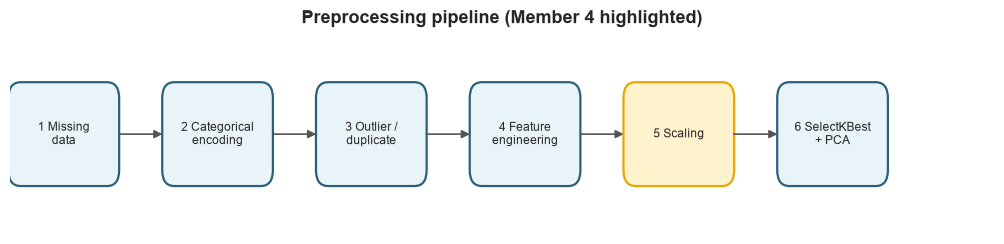

In [7]:
fig, _ = draw_process_flow(
    PIPELINE_STEPS,
    title="Preprocessing pipeline (Member 4 highlighted)",
    highlight=4,
)
fig.savefig(VIZ / "m4_process_flow.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

clean_path = OUT / "m3_cleaned_no_outliers.csv"
if clean_path.exists():
    meta = pd.read_csv(clean_path)
else:
    meta, _ = audit_images(RAW)
    meta, _ = remove_exact_duplicates(meta)
    print("Warning: m3 output missing; using audited unique images.")

# Use a stratified sample for interactive demo speed (full run still OK on ~1k images)
sample = stratified_sample(meta, 120)

X, y, kept = extract_feature_matrix(RAW, sample)
print("Feature matrix:", X.shape, "| classes:", dict(zip(*np.unique(y, return_counts=True))))

scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)

# Persist for Members 5–6 / group pipeline
np.savez_compressed(
    OUT / "m4_scaled_features.npz",
    X_raw=X,
    X_standard=X_std,
    X_minmax=X_mm,
    y=y,
    feature_dim=np.array([X.shape[1]]),
)
kept.to_csv(OUT / "m4_feature_sample_index.csv", index=False)
print("Saved scaled feature matrices to results/outputs/m4_scaled_features.npz")


Feature matrix: (240, 60) | classes: {np.str_('Healthy'): np.int64(120), np.str_('Unhealthy'): np.int64(120)}
Saved scaled feature matrices to results/outputs/m4_scaled_features.npz


## EDA visualizations — before/after scaling & StandardScaler vs MinMax comparison


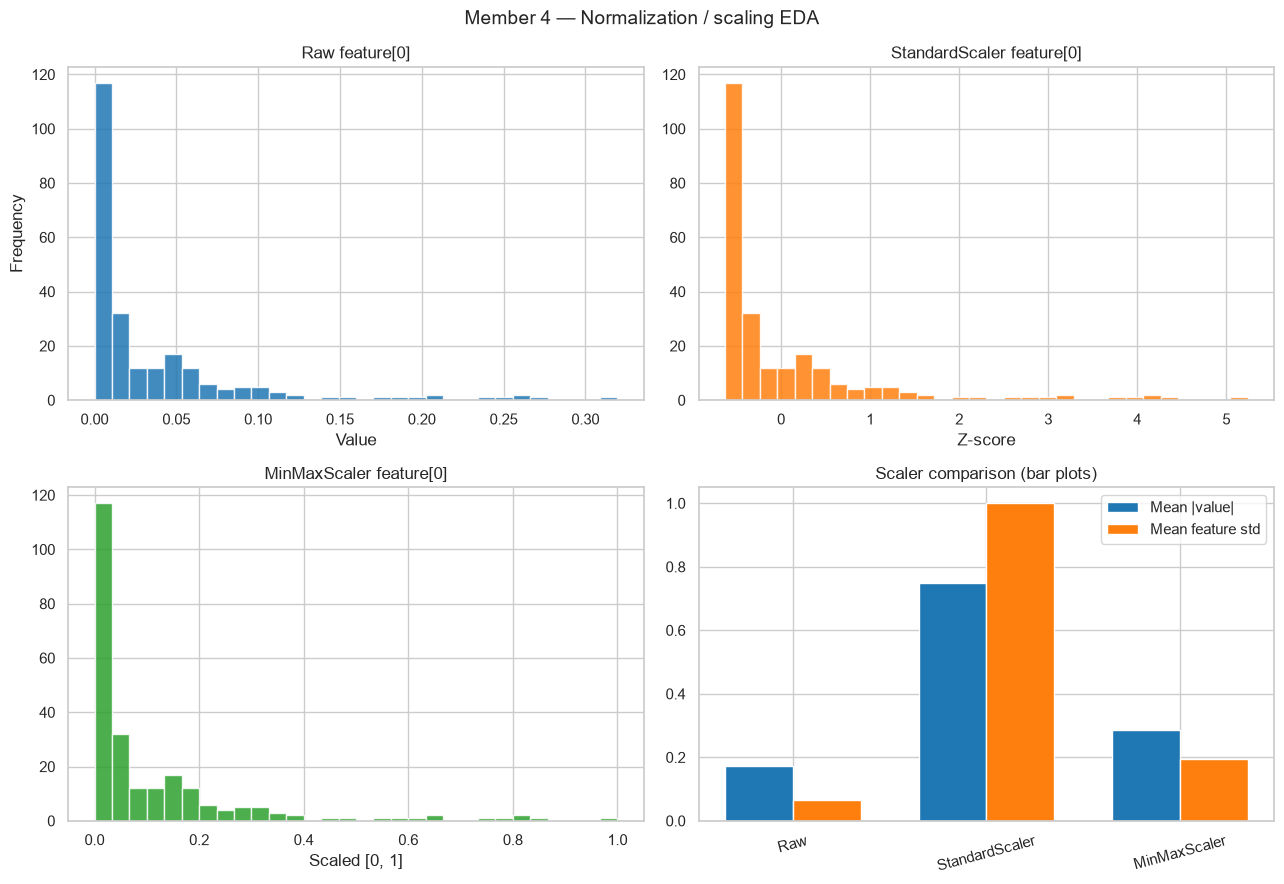

Raw mean/std: 0.0343170166015625 0.054423991590738297
Scaled mean/std: 7.947286384535346e-09 1.0
Interpretation: after StandardScaler, features centre near 0 with comparable variance — safer for distance-based learners.


In [10]:
feat_idx = 0
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].hist(X[:, feat_idx], bins=30, color="#1f77b4", alpha=0.85)
axes[0, 0].set_title(f"Raw feature[{feat_idx}]")
axes[0, 0].set_xlabel("Value")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(X_std[:, feat_idx], bins=30, color="#ff7f0e", alpha=0.85)
axes[0, 1].set_title(f"StandardScaler feature[{feat_idx}]")
axes[0, 1].set_xlabel("Z-score")

axes[1, 0].hist(X_mm[:, feat_idx], bins=30, color="#2ca02c", alpha=0.85)
axes[1, 0].set_title(f"MinMaxScaler feature[{feat_idx}]")
axes[1, 0].set_xlabel("Scaled [0, 1]")

# Compare mean absolute feature scale across methods (bar comparison)
methods = ["Raw", "StandardScaler", "MinMaxScaler"]
mean_abs = [
    float(np.mean(np.abs(X))),
    float(np.mean(np.abs(X_std))),
    float(np.mean(np.abs(X_mm))),
]
stds = [
    float(np.mean(X.std(axis=0))),
    float(np.mean(X_std.std(axis=0))),
    float(np.mean(X_mm.std(axis=0))),
]
x = np.arange(len(methods))
w = 0.35
axes[1, 1].bar(x - w / 2, mean_abs, width=w, label="Mean |value|", color="#1f77b4")
axes[1, 1].bar(x + w / 2, stds, width=w, label="Mean feature std", color="#ff7f0e")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(methods, rotation=15)
axes[1, 1].set_title("Scaler comparison (bar plots)")
axes[1, 1].legend()

fig.suptitle("Member 4 — Normalization / scaling EDA", fontsize=14)
fig.tight_layout()
fig.savefig(VIZ / "m4_scaling_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

print("Raw mean/std:", float(X[:, feat_idx].mean()), float(X[:, feat_idx].std()))
print("Scaled mean/std:", float(X_std[:, feat_idx].mean()), float(X_std[:, feat_idx].std()))
print("Interpretation: after StandardScaler, features centre near 0 with comparable variance — safer for distance-based learners.")
